In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [6]:
DATA_PATH = "/home/victor/projects/ConnectedExplorers/scenario2"
FILE_POSE = os.path.join(DATA_PATH, "poses_log.csv")
FILE_FIEDLER = os.path.join(DATA_PATH, "fiedler_log.csv")

In [7]:
def load_file(file_path):
    df = pd.read_csv(file_path)
    start_time = df['timestamp'].iloc[0]
    df["timestamp"] = df["timestamp"]-start_time
    return df

In [8]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm", # Computer Modern (fonte do LaTeX)
    "font.size": 16,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": ":",
    "grid.color": 'k',
    # Configurações padrão para quiver (setas) para cabeças menores
    "lines.markersize": 8,
})



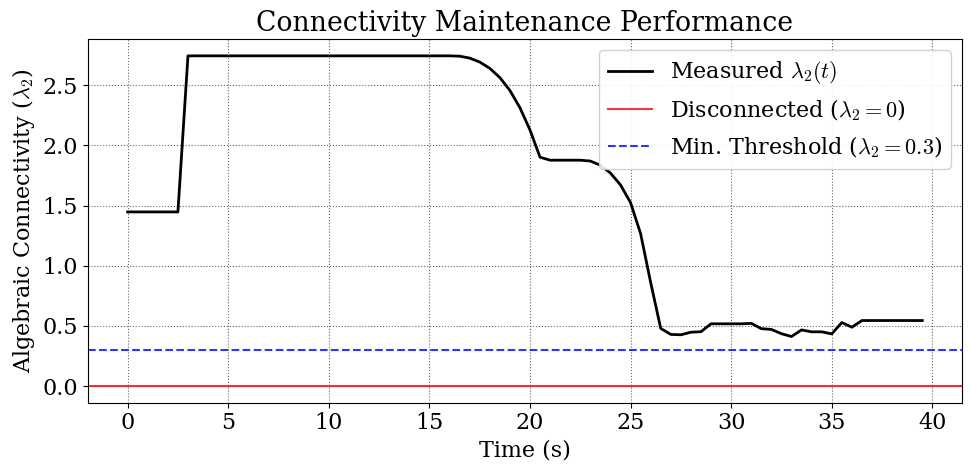

In [9]:
def plot_fiedler(df_fiedler,min_threshold=0.3):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    t_data = df_fiedler['timestamp'] - df_fiedler['timestamp'].iloc[0]
    y_data = df_fiedler['fiedler_value']
    ax.plot(t_data, y_data, color='black', linewidth=2, label=r'Measured $\lambda_2(t)$')
    ax.axhline(0.0, color='red', linestyle='-', linewidth=1.5, alpha=0.8, 
               label=r'Disconnected ($\lambda_2 = 0$)')
    ax.axhline(min_threshold, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, 
               label=rf'Min. Threshold ($\lambda_2 = {min_threshold}$)')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(r"Algebraic Connectivity ($\lambda_2$)")
    ax.set_title("Connectivity Maintenance Performance")
    ax.grid(True, which='both', linestyle=':', alpha=0.6)
    ax.legend(loc='best', frameon=True, framealpha=0.9)
    plt.tight_layout()

    
    plt.show()
df = load_file(FILE_FIEDLER)
plot_fiedler(df)

/tmp/ipykernel_33264/2158948011.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', num_robots)


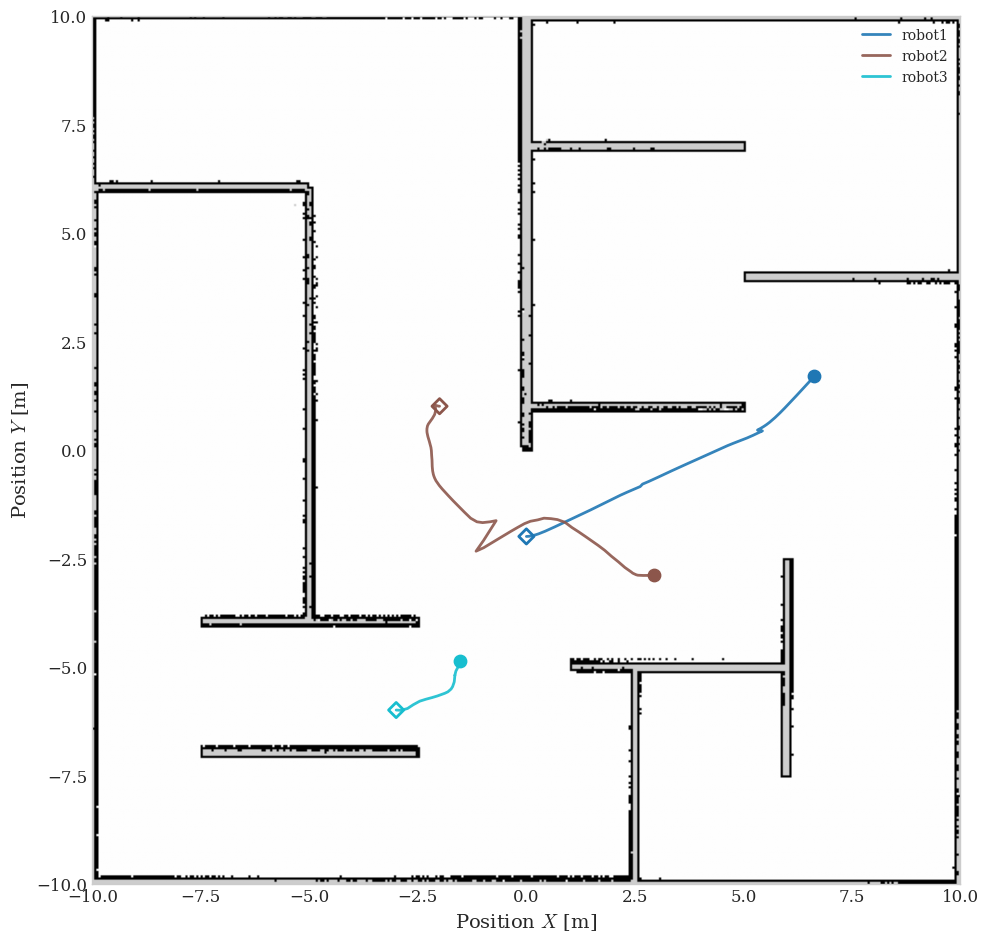

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from itertools import combinations
import matplotlib.image as mpimg 

# --- CONFIGURAÇÕES DO MAPA ---
# Formato: [X_min, X_max, Y_min, Y_max]
MY_MAP_EXTENT = [-10, 10, -10, 10] 
MY_MAP_PATH = "/home/victor/projects/final_proj_MR/src/connected_explorers_bringup/maps/my_map.pgm"

def plot_trajectories_on_map(df_pose, map_image_path, map_extent):
    # --- Configuração Estilo Científico ---
    plt.rcParams.update({
        'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 14,
        'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
        'font.family': 'serif'
    })

    fig, ax = plt.subplots(figsize=(10, 10))

    # ==============================================================================
    # 1. CARREGAR E PLOTAR O MAPA DE FUNDO (CORRIGIDO)
    # ==============================================================================
    try:
        img = mpimg.imread(map_image_path)
        
        # CORREÇÕES DE COR E ORIENTAÇÃO:
        # cmap='gray': Garante que 0=preto e 255=branco.
        # vmin/vmax: Trava a escala de cores para não distorcer o cinza.
        # origin: Removido 'lower' para usar o padrão (topo da imagem = Y máximo).
        # alpha: Removido (ou use 1.0) para o branco ser branco puro e não cinza transparente.
        
        # Detecção automática se a imagem é 0-1 (float) ou 0-255 (int)
        vmax_val = 1.0 if img.max() <= 1.0 else 255
        
        ax.imshow(img, extent=map_extent, cmap='gray', vmin=0, vmax=vmax_val, zorder=0)
        
    except FileNotFoundError:
        print(f"ERRO: Imagem não encontrada: {map_image_path}")

    # ==============================================================================
    # 2. ROTINA DE TRAJETÓRIAS
    # ==============================================================================
    cols = df_pose.columns
    robot_names = sorted([c.replace('_x', '') for c in cols if c.endswith('_x')])
    num_robots = len(robot_names)
    colors = cm.get_cmap('tab10', num_robots)

    start_positions = []
    end_positions = []

    for i, robot in enumerate(robot_names):
        col_x = f"{robot}_x"
        col_y = f"{robot}_y"
        
        data = df_pose[[col_x, col_y]].dropna()
        if data.empty: continue
        
        c = colors(i)
        x_start, y_start = data[col_x].iloc[0], data[col_y].iloc[0]
        x_end, y_end = data[col_x].iloc[-1], data[col_y].iloc[-1]
        start_positions.append((x_start, y_start))
        end_positions.append((x_end, y_end))

        # Trajetória
        ax.plot(data[col_x], data[col_y], label=robot, color=c, linewidth=2, alpha=0.9, zorder=2)
        
        # Marcador Início (Diamante)
        ax.scatter(x_start, y_start, edgecolors=c, facecolors='none', 
                   marker='D', s=60, linewidth=2, zorder=5)
        
        # Marcador Fim (Bolinha)
        ax.scatter(x_end, y_end, color=c, 
                   marker='o', s=80, zorder=5)

    # ==============================================================================
    # 3. CONECTIVIDADE
    # ==============================================================================
    # topologies = [
    #     (start_positions, {'linestyle': ':', 'color': 'black', 'alpha': 0.8}, 'Initial Topology'),
    #     (end_positions,   {'linestyle': '-', 'color': 'black', 'alpha': 0.6}, 'Final Topology')
    # ]

    # for points_list, style, label_text in topologies:
    #     first_line = True
    #     for p1, p2 in combinations(points_list, 2):
    #         label = label_text if first_line else "_nolegend_"
    #         ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
    #                 color=style['color'], linestyle=style['linestyle'], 
    #                 alpha=style['alpha'], linewidth=1, zorder=1, label=label)
    #         first_line = False

    # --- FINALIZAÇÃO ---
    ax.set_xlabel(r"Position $X$ [m]")
    ax.set_ylabel(r"Position $Y$ [m]")
    
    # Importante: Mantém a proporção mas respeita os limites do mapa
    ax.set_aspect('equal')
    ax.set_xlim(map_extent[0], map_extent[1])
    ax.set_ylim(map_extent[2], map_extent[3])
    
    # Grid desligado ou muito suave, pois o mapa já tem detalhes
    ax.grid(False) 

    ax.legend(loc='upper right', framealpha=0.9, fontsize=10, ncol=1)

    plt.tight_layout()
    plt.show()

# --- EXECUÇÃO ---
df = load_file(FILE_POSE)
plot_trajectories_on_map(df, MY_MAP_PATH, MY_MAP_EXTENT)